# Notebook Pengujian
## Tugas Besar 1 IF3270 Pembelajaran Mesin

**Anggota**
- 13523070 - Sebastian Hung Yansen
- 13523082 - Aramazaya

## 0. Import Libraries and Load Data

In [1]:
# 0. Import Libraries and Load Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score

# Load Dataset
train_df = pd.read_csv("dataset/datasetml_2026.csv")
print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


## 1. Exploratory Data Analysis (EDA)

### 1.1. Gambaran Umum Dataset

In [2]:
train_df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [3]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  str    
 3   country                   10000 non-null  str    
 4   university_ranking_band   10000 non-null  str    
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  str    
 9   industry                  10000 non-null  str    
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  str    
dtypes: float64(4), int64(2), str(6)
memory usage: 937.6 KB


### 1.2. Statistik Deskriptif

In [4]:
train_df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


### 1.3. Distribusi Kelas Target

In [5]:
print(train_df['placement_status'].value_counts())
print(train_df['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


### 1.4. Distribusi Fitur Numerik

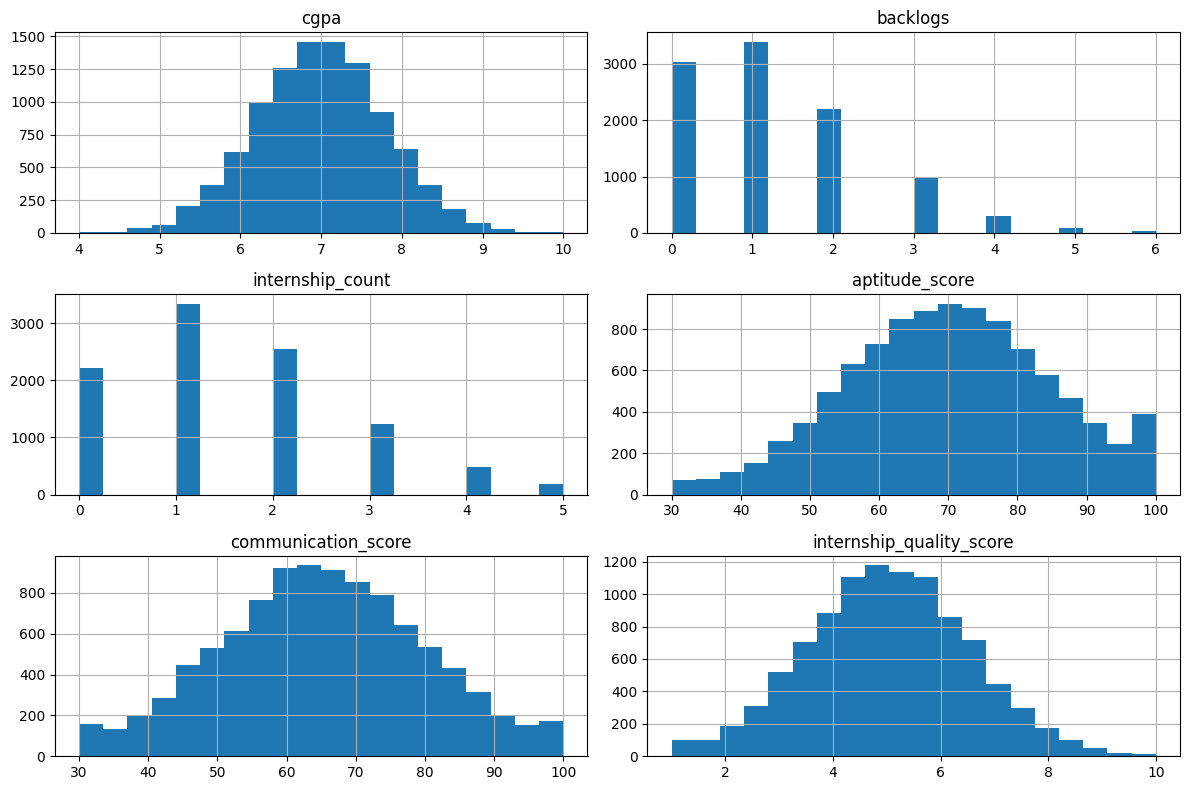

In [6]:
numeric_cols = ["cgpa", "backlogs", "internship_count",
                "aptitude_score", "communication_score",
                "internship_quality_score"]

train_df[numeric_cols].hist(bins=20, figsize=(12, 8)) # histogram
plt.tight_layout()
plt.show()

### 1.5. Distribusi Fitur Kategorikal

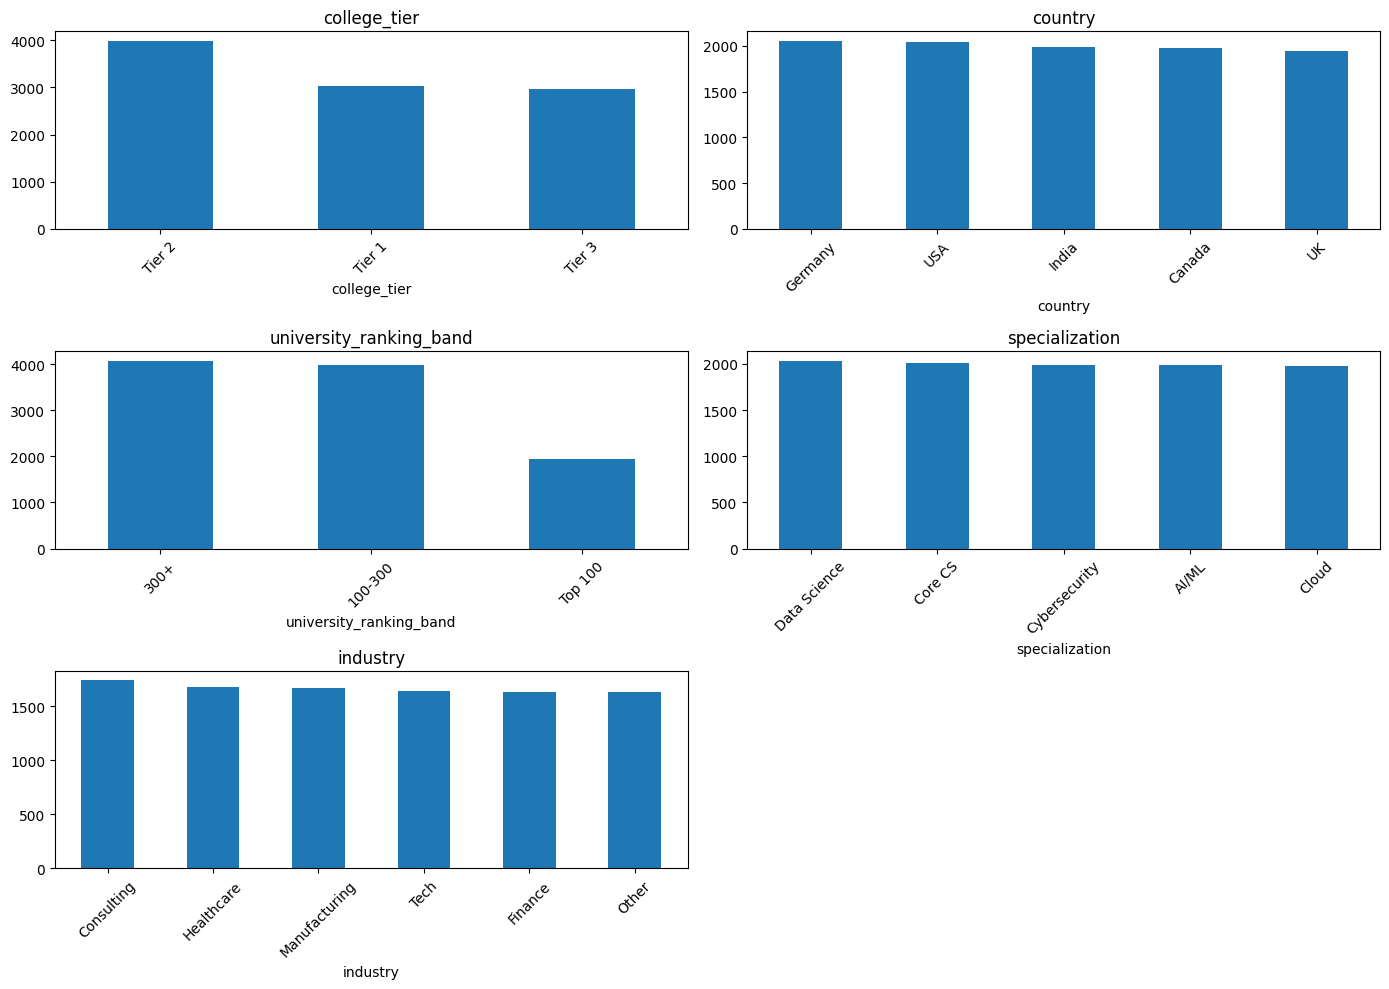

In [7]:
cat_cols = ["college_tier", "country",
            "university_ranking_band",
            "specialization", "industry"]

plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i) # barplot
    train_df[col].value_counts().plot(kind="bar")
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [8]:
df = train_df.copy()

# Target: mapping ke 0/1
y_raw = df["placement_status"].map({"Placed": 1, "Not Placed": 0}).values

# Fitur
X_raw = df.drop(columns=["placement_status"])

cat_cols = X_raw.select_dtypes(include=["object"]).columns
num_cols = X_raw.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", list(cat_cols))
print("Numeric columns:", list(num_cols))

Categorical columns: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numeric columns: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']


C:\Users\Sandra\AppData\Local\Temp\ipykernel_31108\2016672450.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include=["object"]).columns


### One-Hot Encoding untuk fitur kategorikal

In [9]:
enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_cat = enc.fit_transform(X_raw[cat_cols])
X_num = X_raw[num_cols].values

X = np.concatenate([X_num, X_cat], axis=1)
y = y_raw  # scalar 0/1, shape (10000,)

print("Final feature shape:", X.shape)
print("Final target shape:", y.shape)

Final feature shape: (10000, 28)
Final target shape: (10000,)


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_raw[num_cols].values)
X = np.concatenate([X_num_scaled, X_cat], axis=1)

## Train/Validation Split

In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape, "X_val:", X_val.shape)
print("y_train class distribution:", np.unique(y_train, return_counts=True))

X_train: (8000, 28) X_val: (2000, 28)
y_train class distribution: (array([0, 1]), array([3078, 4922]))


In [ ]:
from importlib import reload
import ffnn
reload(ffnn)
from ffnn import FeedForwardNN

model = FeedForwardNN(
    neurons = [X_train.shape[1], 16, 8, 1],
    activation_function = ["tanh", "tanh", "sigmoid"],
    loss_function = "mse",
    learning_rate = 0.01,
    loss_threshold = 0.01,
    epochs = 50,
    weight_init = "normal",
    weight_variance = 0.01,
    batch_size = 1,
    verbose = True,
)

In [13]:
model.fit(X_train, y_train)
y_pred_proba = model.predict(X_val)   # shape (2000,) — raw argmax of 1 neuron = always 0
y_pred = (y_pred_proba >= 0.5).astype(int)  # threshold at 0.5
accuracy = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", round(accuracy, 3))

Epoch 1/50, Loss: 0.237669, y=0: 0.629686, y=1: 0.629691
Epoch 2/50, Loss: 0.236824, y=0: 0.629698, y=1: 0.629709
Epoch 3/50, Loss: 0.236823, y=0: 0.629693, y=1: 0.629718
Epoch 4/50, Loss: 0.236818, y=0: 0.629675, y=1: 0.62974
Epoch 5/50, Loss: 0.236802, y=0: 0.629565, y=1: 0.62983
Epoch 6/50, Loss: 0.236631, y=0: 0.627554, y=1: 0.631047
Epoch 7/50, Loss: 0.211574, y=0: 0.178823, y=1: 0.802246
Epoch 8/50, Loss: 0.164030, y=0: 0.127921, y=1: 0.767783
Epoch 9/50, Loss: 0.163017, y=0: 0.125737, y=1: 0.772645
Epoch 10/50, Loss: 0.162758, y=0: 0.129169, y=1: 0.776337
Epoch 11/50, Loss: 0.162582, y=0: 0.131831, y=1: 0.778343
Epoch 12/50, Loss: 0.162439, y=0: 0.135349, y=1: 0.779245
Epoch 13/50, Loss: 0.162316, y=0: 0.13982, y=1: 0.78118
Epoch 14/50, Loss: 0.162201, y=0: 0.142726, y=1: 0.783744
Epoch 15/50, Loss: 0.162095, y=0: 0.143574, y=1: 0.784982
Epoch 16/50, Loss: 0.161995, y=0: 0.14395, y=1: 0.786005
Epoch 17/50, Loss: 0.161908, y=0: 0.145029, y=1: 0.786898
Epoch 18/50, Loss: 0.161822,

In [14]:
print(np.unique(y_pred, return_counts=True))

(array([0, 1]), array([ 650, 1350]))
